<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/tableau_periodique_spectres_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tableau Périodique des Spectres de Raies d'Émission

Ce notebook génère un tableau périodique où chaque case affiche le spectre de raies d'émission visible de l'élément correspondant (atome neutre, état I).

Code adapté de l'auteur original David Alberto (www.astrolabe-science.fr)

**Source des données** : [atomic-spectra.net](https://www.atomic-spectra.net) — fichier `wavelength_tables_crop.csv`  
La colonne `Est. Visual Brightness` fournit une intensité visuelle estimée et arbitrée, bien supérieure à l'échelle discrète saturée du NIST brut.

## 1. Imports

In [1]:
# ── Bibliothèques standard ──────────────────────────────────────────────────
import io

# ── Calcul & données ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ───────────────────────────────────────────────────────────
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Colab ────────────────────────────────────────────────────────────────────
from google.colab import files
from IPython.display import display

%matplotlib inline

## 2. Configuration

In [2]:
# ── Plage spectrale visible (nm) ────────────────────────────────────────────
XMIN, XMAX = 380, 750

# ── Nombre max de raies retenues par élément ────────────────────────────────
N_RAIES = 15

# ── Seuil d'intensité relative minimale (0–1) ────────────────────────────────
FILTRE = 0.01

# ── Résolution de regroupement des composantes fines (nm) ───────────────────
RESOLUTION = 0.05

# ── Épaisseur des raies ──────────────────────────────────────────────────────
EPAISSEUR = 0.7

# ── Couleurs ─────────────────────────────────────────────────────────────────
FOND = '#121212'

# ── Police ───────────────────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'DejaVu Sans'

## 3. Données du tableau périodique

In [3]:
# Numéros atomiques
NUMERO_ATOMIQUE = {
    'H':1,  'He':2, 'Li':3,  'Be':4,  'B':5,   'C':6,   'N':7,   'O':8,
    'F':9,  'Ne':10,'Na':11, 'Mg':12, 'Al':13, 'Si':14, 'P':15,  'S':16,
    'Cl':17,'Ar':18,'K':19,  'Ca':20, 'Sc':21, 'Ti':22, 'V':23,  'Cr':24,
    'Mn':25,'Fe':26,'Co':27, 'Ni':28, 'Cu':29, 'Zn':30, 'Ga':31, 'Ge':32,
    'As':33,'Se':34,'Br':35, 'Kr':36, 'Rb':37, 'Sr':38, 'Y':39,  'Zr':40,
    'Nb':41,'Mo':42,'Tc':43, 'Ru':44, 'Rh':45, 'Pd':46, 'Ag':47, 'Cd':48,
    'In':49,'Sn':50,'Sb':51, 'Te':52, 'I':53,  'Xe':54, 'Cs':55, 'Ba':56,
    'La':57,'Hf':72,'Ta':73, 'W':74,  'Re':75, 'Os':76, 'Ir':77, 'Pt':78,
    'Au':79,'Hg':80,'Tl':81, 'Pb':82, 'Bi':83, 'Po':84, 'At':85, 'Rn':86,
}

# Position (colonne, ligne) dans le tableau périodique — 1-based
POSITIONS = {
    'H':(1,1),  'He':(18,1),
    'Li':(1,2), 'Be':(2,2), 'B':(13,2), 'C':(14,2), 'N':(15,2), 'O':(16,2), 'F':(17,2),  'Ne':(18,2),
    'Na':(1,3), 'Mg':(2,3), 'Al':(13,3),'Si':(14,3),'P':(15,3), 'S':(16,3), 'Cl':(17,3), 'Ar':(18,3),
    'K':(1,4),  'Ca':(2,4), 'Sc':(3,4), 'Ti':(4,4), 'V':(5,4),  'Cr':(6,4), 'Mn':(7,4),  'Fe':(8,4),
    'Co':(9,4), 'Ni':(10,4),'Cu':(11,4),'Zn':(12,4),'Ga':(13,4),'Ge':(14,4),'As':(15,4), 'Se':(16,4),
    'Br':(17,4),'Kr':(18,4),
    'Rb':(1,5), 'Sr':(2,5), 'Y':(3,5),  'Zr':(4,5), 'Nb':(5,5), 'Mo':(6,5), 'Tc':(7,5),  'Ru':(8,5),
    'Rh':(9,5), 'Pd':(10,5),'Ag':(11,5),'Cd':(12,5),'In':(13,5),'Sn':(14,5),'Sb':(15,5), 'Te':(16,5),
    'I':(17,5), 'Xe':(18,5),
    'Cs':(1,6), 'Ba':(2,6), 'La':(3,6), 'Hf':(4,6), 'Ta':(5,6), 'W':(6,6),  'Re':(7,6),  'Os':(8,6),
    'Ir':(9,6), 'Pt':(10,6),'Au':(11,6),'Hg':(12,6),'Tl':(13,6),'Pb':(14,6),'Bi':(15,6), 'Po':(16,6),
    'At':(17,6),'Rn':(18,6),
}

LISTE_SYMBOLES = list(POSITIONS.keys())

## 4. Chargement du fichier wavelength_tables_crop.csv

In [4]:
# Upload du fichier depuis votre PC (une seule fois par session Colab)
uploaded = files.upload()
nom_fichier = list(uploaded.keys())[0]

df_all = pd.read_csv(io.BytesIO(uploaded[nom_fichier]))
df_all['wl_nm'] = pd.to_numeric(df_all['Wavelength, Å'], errors='coerce') / 10.0
df_all['vis']   = pd.to_numeric(df_all['Est. Visual Brightness'].astype(str).str.strip(), errors='coerce')
df_all['rel']   = pd.to_numeric(df_all['Rel. Intensity'].astype(str).str.strip(), errors='coerce')

print(f"Fichier chargé : {nom_fichier}  ({len(df_all)} raies au total)")

Saving wavelength_tables_crop.csv to wavelength_tables_crop (1).csv
Fichier chargé : wavelength_tables_crop (1).csv  (46575 raies au total)


## 5. Fonctions de traitement et de tracé

In [5]:
# ── Colormap visible ────────────────────────────────────────────────────────
CMAP = plt.get_cmap('turbo')
NORM = mpl.colors.Normalize(vmin=XMIN, vmax=XMAX)


def extraire_element(df, symbole, xmin=XMIN, xmax=XMAX):
    """
    Retourne les raies de l'atome neutre (Spectrum='I') d'un élément
    dans la fenêtre spectrale [xmin, xmax] nm.
    """
    masque = (
        (df['Element'] == symbole) &
        (df['Spectrum'] == 'I') &
        (df['wl_nm'] >= xmin) &
        (df['wl_nm'] <= xmax)
    )
    return df[masque].copy()


def calculer_score(data):
    """
    Score d'intensité hybride :
      - Est. Visual Brightness en priorité (intensité visuelle estimée et arbitrée)
      - Rel. Intensity en fallback à 10% du max visuel si Visual absent
    """
    data = data.copy()
    vis_max = data['vis'].max()
    rel_max = data['rel'].max()
    fallback = (data['rel'] / rel_max * vis_max * 0.1) if (rel_max > 0 and vis_max > 0) else data['rel']
    data['score'] = data['vis'].fillna(fallback)
    return data[data['score'] > 0]


def filtrage_top_n(data, n=N_RAIES, seuil=FILTRE, resolution=RESOLUTION):
    """
    Regroupe les composantes de structure fine (fenêtre 'resolution' nm),
    sélectionne les n raies les plus intenses, normalise 0–1,
    élimine les raies sous le seuil.
    """
    data = data.copy()
    data['wl_g'] = (data['wl_nm'] / resolution).round() * resolution
    grouped = data.groupby('wl_g', as_index=False).agg(
        wl=('wl_nm', 'mean'),
        score=('score', 'sum')
    )
    top = grouped.sort_values('score', ascending=False).head(n).copy()
    top['int'] = top['score'] / top['score'].max()
    return top[top['int'] >= seuil]


def trace_spectre(data, axe, symb):
    """
    Trace le spectre de raies sur 'axe'. Chaque raie est colorée
    selon sa longueur d'onde via le colormap visible (turbo).
    """
    axe.set_facecolor('black')
    axe.set_xlim(XMIN, XMAX)
    axe.set_ylim(0, 1.05)
    for _, row in data.iterrows():
        axe.plot([row.wl, row.wl], [0, row['int']],
                 lw=EPAISSEUR, color=CMAP(NORM(row.wl)))
    _etiquette(axe, symb)


def axe_vide(axe, symb):
    """Case bleue pour un élément sans données disponibles."""
    axe.set_facecolor('midnightblue')
    axe.set_xlim(XMIN, XMAX)
    axe.set_ylim(0, 1)
    _etiquette(axe, symb)


def _etiquette(axe, symb):
    """Affiche le symbole et le numéro atomique en haut à gauche de la case."""
    axe.text(0.03, 0.97,
             f"{symb}\n{NUMERO_ATOMIQUE.get(symb, '')}",
             transform=axe.transAxes,
             fontsize=9, color='white',
             va='top', ha='left', fontweight='bold')

## 6. Construction de la figure

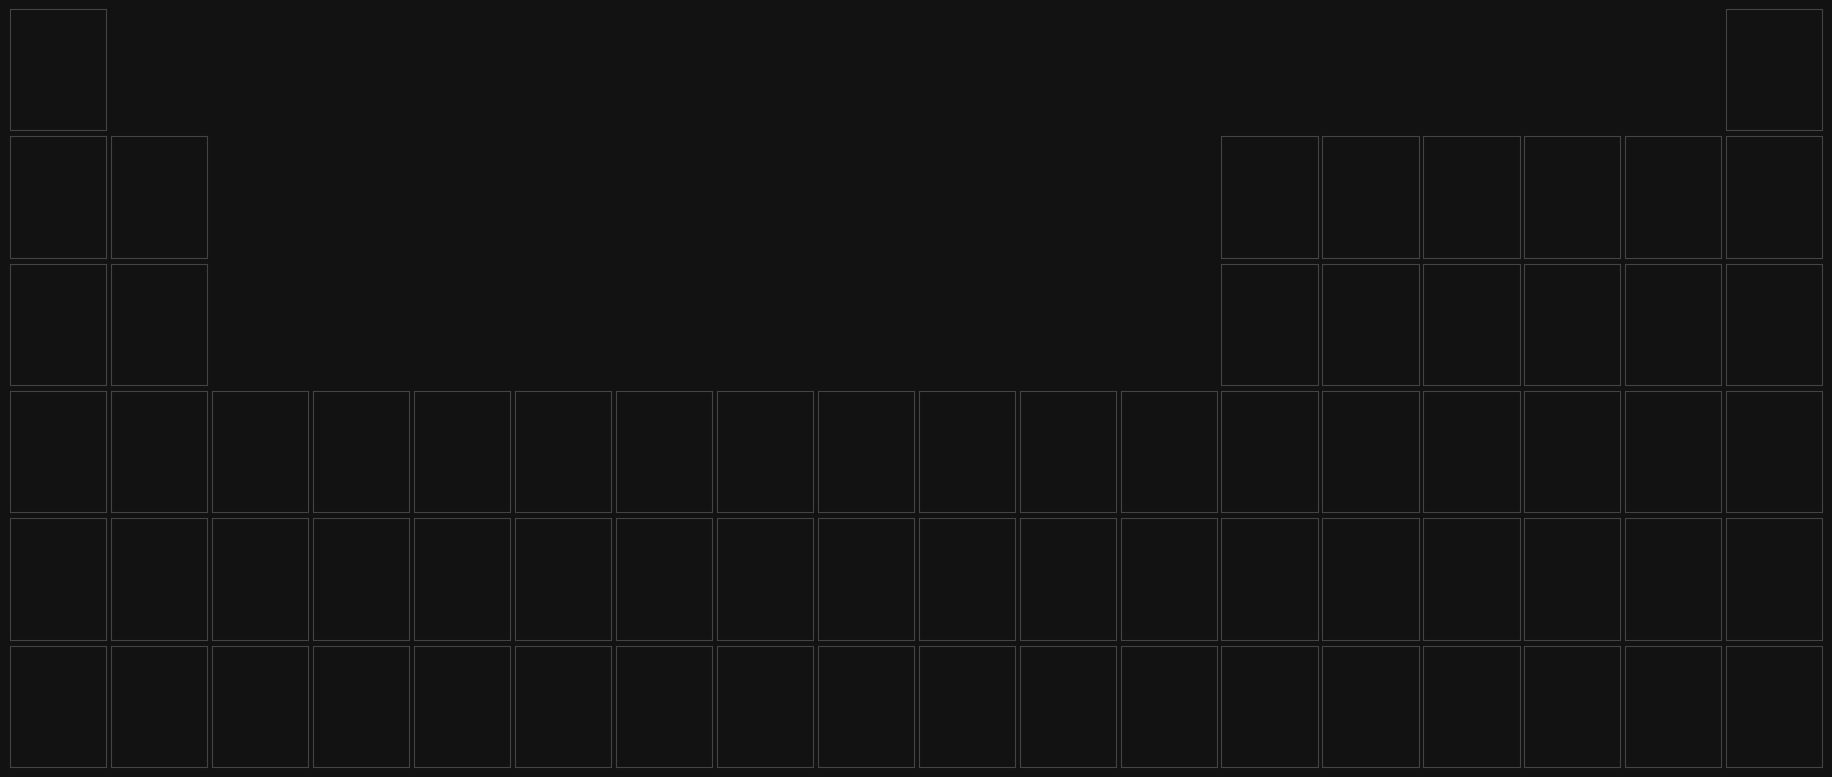

In [6]:
N_LIGNES, N_COLS = 6, 18

fig = plt.figure(figsize=(59.4 / 2.54, 25 / 2.54))
fig.patch.set_facecolor(FOND)

gs   = gridspec.GridSpec(N_LIGNES, N_COLS, figure=fig, hspace=0.05, wspace=0.05)
axes = np.array([
    [fig.add_subplot(gs[i, j]) for j in range(N_COLS)]
    for i in range(N_LIGNES)
])

# Style global des axes
for axe in axes.flat:
    axe.set_xticks([])
    axe.set_yticks([])
    axe.patch.set_facecolor(FOND)
    for spine in axe.spines.values():
        spine.set_color('#444444')

# Masquage des cases vides du tableau périodique
for j in range(1, 17):   # ligne 1 : H et He seulement
    axes[0, j].axis('off')
for j in range(2, 12):   # lignes 2 et 3 : bloc s et p séparés
    axes[1, j].axis('off')
    axes[2, j].axis('off')

## 7. Tracé des spectres

In [7]:
manquants = []

for symb in LISTE_SYMBOLES:
    col, lig = POSITIONS[symb]
    axe = axes[lig - 1, col - 1]

    df_elem = extraire_element(df_all, symb)

    if df_elem.empty:
        manquants.append(symb)
        axe_vide(axe, symb)
        continue

    try:
        df_elem = calculer_score(df_elem)
        df_plot = filtrage_top_n(df_elem)

        if df_plot.empty:
            axe_vide(axe, symb)
        else:
            trace_spectre(df_plot, axe, symb)
    except Exception as e:
        print(f"⚠  Erreur pour {symb} : {e}")
        axe_vide(axe, symb)

if manquants:
    print(f"Éléments sans données ({len(manquants)}) : {manquants}")
else:
    print("Tous les éléments ont été tracés.")

Éléments sans données (1) : ['At']


## 8. Titre et affichage

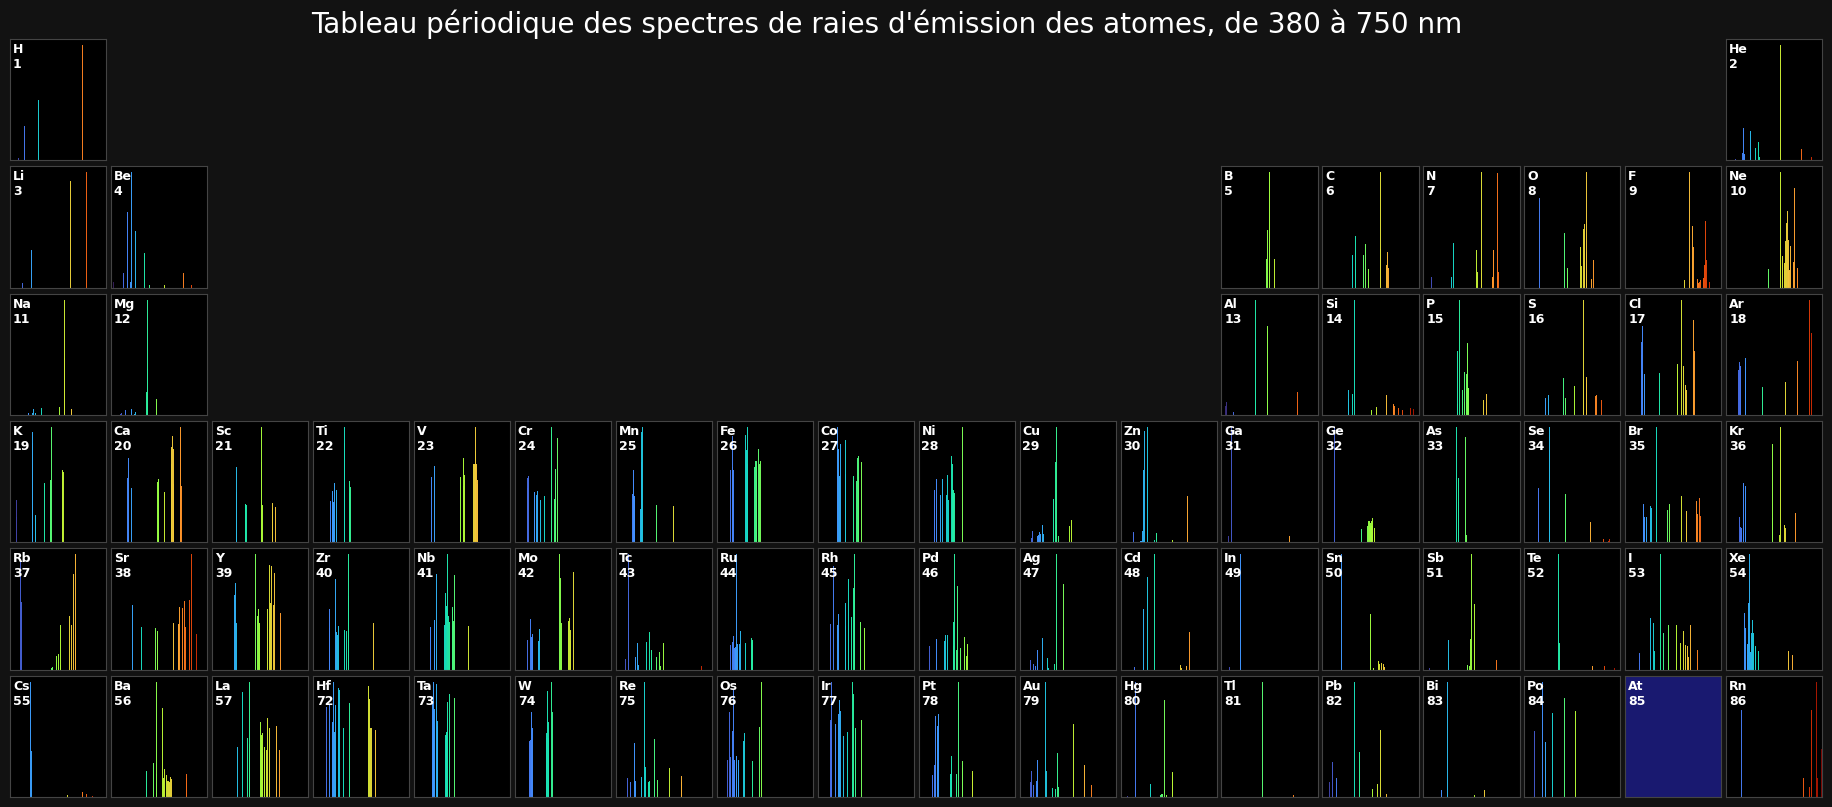

<Figure size 640x480 with 0 Axes>

In [8]:
# Récupérer la position du bord supérieur de la ligne 1 en coordonnées figure
bbox_H  = axes[0, 0].get_position()   # H  — col 1, ligne 1
bbox_He = axes[0, 17].get_position()  # He — col 18, ligne 1

fig.text(
    0.5,                   # centré horizontalement
    bbox_H.y1,             # même hauteur que le bord supérieur des cases H et He
    f"Tableau périodique des spectres de raies d'émission des atomes, de {XMIN} à {XMAX} nm",
    fontsize=20,
    ha='center', va='bottom',   # texte au-dessus de cette ligne
    color='white',
    transform=fig.transFigure,
)

plt.tight_layout()
display(fig)

## 9. Sauvegarde

In [9]:
fig.savefig('tableau_periodique_spectres.pdf', bbox_inches='tight', dpi=150)
fig.savefig('tableau_periodique_spectres.png', bbox_inches='tight', dpi=250)
print("Sauvegardé : tableau_periodique_spectres.pdf  et  .png")

files.download('tableau_periodique_spectres.png')
files.download('tableau_periodique_spectres.pdf')

Sauvegardé : tableau_periodique_spectres.pdf  et  .png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>